# Clustering Trajectories with Expectation-Maximization

Let's apply last session's knowledge to trajectory clustering.

First, we'll import the scientific and plotting libraries.

In [70]:
import numpy as np
import pylab as pl
import scipy as sp
import random

Now, let's import two small modules we have prepared for this session. The first one contains some [trajectory data][1], and the second one is a collection of useful functions we are going to use througout this session.

[1]: http://homepages.inf.ed.ac.uk/rbf/FORUMTRACKING/ "Edinburgh Informatics Forum Pedestrian Database."

In [71]:
import sys
sys.path.append('/content/mooc/modules/')

from behavior_data import data
import behavior_helper as bh
data = data[:500]

First, we'll take a look at those trajectories.

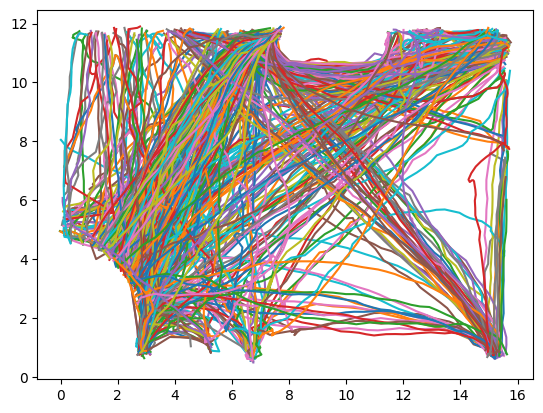

In [72]:
bh.plot_trajectories( data )

When inspecting the figure, some trajectories that seem to "belong together". Finding those groups can be done with the EM algorithm discussed last week. However, that algorithm was designed for point data, which is somewhat different from trajectory data.

At the end, this is very similar to the two-dimensional data we were using on last session, except that we have several points per data sample (trajectory). Thus, a trajectory may be represented as a sequence $S_n$ of points.

$$S_n = \{p^1_n, \cdots, p^T_n\}$$

Where each point $p^t_n$ corresponds to the position of person $n$ at time $t$.

$$p^t_n = (x^t_n, y^t_n)$$

Similarly, if we assume all the clusters to have the same covariance $\Sigma$, we can represent each cluster $\theta_m$ as a sequence of two-dimensional mean values.

$$\theta_m = \{\mu^1_m, \cdots, \mu^T_m\}$$

In order to compute the expectations, we'll make the strong assumption that consecutive positions in the trajectory are mutually independent. This way, we can compute expectations by simply multiplying.

$$E^n_m = \prod_{t = 1}^{T}e^{-(p^t_n - \mu^t_m) \Sigma^{-1}(p^t_n - \mu^t_m)}$$

Before programming the respective functions, we need to do something about $T$ which is assumed to be the same all around while, in practice, trajectories may vary in length. We'll solve this by preprocessing the data, padding shorter trajectories with their last known position (i.e. assuming that the person is resting). This has already been done for the data we are using.

Now, we can write the t_gaussian, t_zero and t_cummulate functions.

In [73]:
def t_zero( trajectory ):
    trajectory *= 0.0

def t_cummulate( weight, t1, t2 ):
    t1 += weight * t2

def t_gaussian( mean, covariance, value ):
    inv = np.linalg.inv( covariance )
    diff = mean - value
    dist = -0.5 * np.dot( np.dot( diff, inv ), diff.transpose() )
    exp = np.exp( np.diagonal( dist ) )
    return np.multiply.reduce( exp )

We also need a way to initialize the cluster mean values. At this point we are going to do it by selecting trajectories at random.

In [74]:
T = data.shape[1]
M = 10
N = data.shape[0]

means = np.zeros( (M, T, 2) )
visited = random.sample( list(np.arange( N )), M )
for m, n in zip( range( M ), visited ):
    means[m] = data[n]

Let's plot the resulting means.

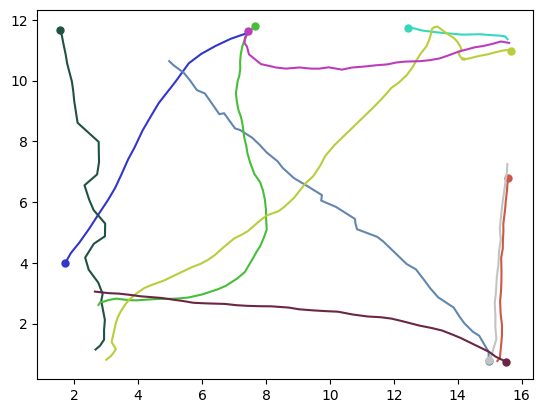

In [75]:
bh.plot_trajectories( means )

We also initialize the covariance.

In [76]:
covariance = np.array( [[16.0, 0.0], [0.0, 16.0]] )

Now, let's bring back the expectation and maximization functions from last session.

In [77]:
def expectation( data, means, covariance, f ):
    '''Expectation step'''
    N = len( data )  # Number of trajectories
    M = len( means ) # Number of clusters
    e = np.zeros( ( N, M ) ) # Expectation array
    for n in range( N ):
        for m in range( M ):
            e[n, m] = f( means[m], covariance, data[n] )
    return e

def maximization( data, e, means, zero, cummulate ):
    '''Maximization step'''
    N = len( data )
    M = len( means )
    for m in range( M ):
        zero( means[m] )
        for n in range( N ):
            cummulate( e[n, m], means[m], data[n] )
        means[m] /= np.sum( e[:, m] ) # Normalize

And let's iterate.

NameError: name 'xrange' is not defined

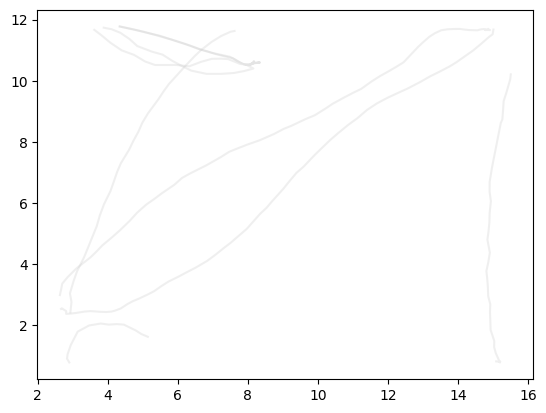

In [78]:
e = expectation( data, means, covariance, t_gaussian )
maximization( data, e, means, t_zero, t_cummulate )
bh.plot_clusters( e, data )

In [ ]:
for i in range( 10 ):
    e = expectation( data, means, covariance, t_gaussian )
    maximization( data, e, means, t_zero, t_cummulate )
bh.plot_clusters( e, data )

In [ ]:
bh.plot_trajectories( means )

##Initializing new clusters

After all those iterations, it seems that not all clusters are contributing in the same way, as shown in the following plot.

In [ ]:
cluster_contribs = np.sum( e, 0 )
pl.bar( arange( M ), cluster_contribs, color = bh.generate_palette( M ) )

Also, not al trajectories are well represented.

In [ ]:
traj_contribs = np.sum( e, 1 )
pl.bar( arange( N ), traj_contribs )

In [ ]:
def worst_cluster( e ):
    M = e.shape[1]
    with_e = np.sum( np.max( e, 1 ) ) # Sum of best cluster scores
    cluster_scores = np.zeros( (M, ) )
    for m in range( M ):
        without_e = e.copy()
        without_e[:, m] = 0. # Exclude current cluster
        cluster_scores[m] = with_e - np.sum( np.max( without_e, 1 ) )
    index = np.argmin( cluster_scores )
    score = np.min( cluster_scores )
    return index, score

def worst_trajectory( e, c_index, c_score, visited, data, covariance ):
    N = data.shape[0]
    M = e.shape[1]


    # Sort trajectories by contribution
    traj_contribs = np.sum( e, 1 )
    traj_contribs[visited] = 1E6 # Ignore visited
    sorted_trajs = np.argsort( traj_contribs )

    tmp_e = e.copy()
    tmp_e[:, c_index] = 0.0
    without_e = np.sum( np.max( e, 1 ) )
    for k in sorted_trajs:
        for n in range( N ):
            tmp_e[n, c_index] = t_gaussian( data[k], covariance, data[n] )
        score = np.sum( np.max( tmp_e, 1 ) ) - without_e
        if score > c_score:
            return k, score
    return -1, 0.0

In [ ]:
iterations = 20
for i in range( iterations ):
    for j in range( 5 ):
        e = expectation( data, means, covariance, t_gaussian )
        maximization( data, e, means, t_zero, t_cummulate )
    if i < iterations - 1:
        c_index, c_score = worst_cluster( e )
        t_index, t_score = worst_trajectory( e, c_index, c_score, visited, data, covariance )
        if t_index == -1:
            break
        print("Replacing cluster %i with trajectory %i" % ( c_index, t_index ))
        means[c_index] = data[t_index]
        visited.append( t_index )
bh.plot_clusters( e, data )

In [ ]:
bh.plot_trajectories( means )

In [ ]:
cluster_contribs = np.sum( e, 0 )
pl.bar( arange( M ), cluster_contribs, color = bh.generate_palette( M ) )

In [ ]:
traj_contribs = np.sum( e, 1 )
pl.bar( arange( N ), traj_contribs )